# Validating the Code

Author: Vicente Pedreros A.

The goal of this notebook is to validate it against `CLASS`

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import scienceplots
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
plt.style.use(['science', 'bright','vpedre'])

import VP_pert as vp
from classy import Class
from scipy.integrate import solve_ivp
import sys, os

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# Define cosmological parameters, taken from EuclidEmulator2, centre values

H0_kms = 67.00
h = H0_kms / 100
Om_b = 0.049
Om_cdm = 0.27
Om_m = Om_b + Om_cdm
Om_de = 1.0 - Om_m  # We restricty ourselves to the flat universe

vp_base = {'H0 (km/s/Mpc)': H0_kms, 
           'H0 (1/Mpc)'   : H0_kms / vp.c_kms,
           'h'            : h,
           'Omega_c0'     : Om_cdm,
           'Omega_b0'     : Om_b,
           'Omega_m0'     : Om_m,
           'cs2'          : 1.0}

# DE model catalogue  {label: (w0, wa)}
de_models = {
    r'$\Lambda$CDM'             : (-1.0, 0.0),
    r'$w_0=-0.7, w_a=-0.6$'     : (-0.7, -0.6),
    r'$w_0=-0.7, w_a=0.0$'      : (-0.7, 0.0),
    r'$w_0=-0.7, w_a=0.6$'      : (-0.7, 0.6),
}

k_default = 1e-3

In [3]:
de_models['$w_0=-0.7, w_a=-0.6$'][0]

-0.7

In [4]:
# # First we create a dictionary and compute every model with CLASS
# base_params = {
#     'output'         : 'mPk, mTk',
#     'gauge'          : 'newtonian',
#     'h'              : h,
#     'Omega_b'        : Om_b,
#     'Omega_cdm'      : Om_cdm,
#     'N_ncdm'         : 0,
#     'N_ur'           : 3.046,
#     'P_k_max_1/Mpc'  : 10.0,
#     'z_max_pk'       : 100.0,
#     'k_output_values': k_default,
# }

# lcdm_params = base_params | {
#     'Omega_Lambda' : Om_de
# }

# w0wa1_params = base_params | {
#     'Omega_fld' : Om_de,
#     'w0_fld'    : de_models['$w_0=-0.7, w_a=-0.6$'][0],
#     'wa_fld'    : de_models['$w_0=-0.7, w_a=-0.6$'][1],
# }

# w0wa2_params = base_params | {
#     'Omega_fld' : Om_de,
#     'w0_fld'    : de_models['$w_0=-0.7, w_a=-0.6$'][0],
#     'wa_fld'    : de_models['$w_0=-0.7, w_a=-0.6$'][1],
# }

# w0wa3_params = base_params | {
#     'Omega_fld' : Om_de,
#     'w0_fld'    : de_models['$w_0=-0.7, w_a=-0.6$'][0],
#     'wa_fld'    : de_models['$w_0=-0.7, w_a=-0.6$'][1],
# }

# class_dict = {}

# class_dict['lcdm'] = Class()
# class_dict['lcdm'].set(lcdm_params)
# class_dict['lcdm'].compute()

# class_dict['w0wa1'] = Class()
# class_dict['w0wa1'].set(w0wa1_params)
# class_dict['w0wa1'].compute()

# class_dict['w0wa2'] = Class()
# class_dict['w0wa2'].set(w0wa2_params)
# class_dict['w0wa2'].compute()

# class_dict['w0wa3'] = Class()
# class_dict['w0wa3'].set(w0wa3_params)
# class_dict['w0wa3'].compute()

In [ ]:
# Now we define a wrapper for our solver

def run_class(w0=-1.0, wa=0.0):
    params = {
        'output'         : 'mPk, mTk',
        'gauge'          : 'newtonian',
        'h'              : h,
        'Omega_b'        : Om_b,
        'Omega_cdm'      : Om_cdm,
        'N_ncdm'         : 0,
        'N_ur'           : 3.046,
        'P_k_max_1/Mpc'  : 10.0,
        'z_max_pk'       : 100.0,
        'k_output_values': k_default,
    }
    if w0 == -1.0 and wa == 0.0:
        params['Omega_Lambda'] = Om_de
    else:
        params['Omega_fld'] = Om_de
        params['w0_fld']    = w0
        params['wa_fld']    = wa
        params['cs2_fld']   = 1.0
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()
    return cosmo


def run_vp(w0=-1.0, wa=0.0, k=k_default, a_ini=1e-4):
    p = dict(vp_base)
    p['w0'], p['wa'] = w0, wa
    phi_ini     = -1e-9
    H_ini       = vp.Hubble(a_ini, p)
    H_conf      = a_ini * H_ini
    delta_m_ini = -2.0 * phi_ini * (1.0 + k**2 / (3.0 * H_conf**2))
    vm_ini      =  2.0 * k**2 * phi_ini / (3.0 * H_conf)
    sol = solve_ivp(
        vp.rhs_pert, (a_ini, 1.0), [delta_m_ini, vm_ini, 0.0, 0.0, phi_ini],
        args=(k, p), method='RK45', dense_output=True, rtol=1e-9, atol=1e-12,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol, p


def get_delta_m_vp(sol, z_arr, idx_X=0):
    """Returns D(z) = delta_X(z)
    0,1,2,3 = delta_m, theta_m, delta_de, theta_de
    """
    aa = 1.0 / (1.0 + np.asarray(z_arr))
    return np.array([sol.sol([a])[idx_X][0] for a in aa])


def get_delta_m_class(cosmo, pert_name, z_ini=99):
    a_class = cosmo.get_perturbations()['scalar'][0]['a']
    mask = a_class > 1/(1+z_ini)
    a_class = a_class[mask]
    z_class = 1/a_class - 1

    if pert_name == 'delta_m':
        delta_m = cosmo.get_perturbations()['scalar'][0]['delta_cdm'] + cosmo.get_perturbations()['scalar'][0]['delta_b']
        delta_X = delta_m[mask]
    elif pert_name == 'delta_de':
        try:
            delta_fld = cosmo.get_perturbations()['scalar'][0]['delta_fld']
            delta_X = delta_fld[mask]
        except:
            delta_X = np.zeros_like(z_class)
    elif pert_name == 'theta_m':
        theta_m = cosmo.get_perturbations()['scalar'][0]['theta_cdm'] + cosmo.get_perturbations()['scalar'][0]['theta_b']
        delta_X = theta_m[mask]
    elif pert_name == 'theta_de':
        try:
            theta_fld = cosmo.get_perturbations()['scalar'][0]['theta_fld']
            delta_X = theta_fld[mask]
        except:
            delta_X = np.zeros_like(z_class)
    return delta_X, z_class


def get_delta_de_vp(sol, z_arr):
    """Returns delta_de(z)"""
    aa = 1.0 / (1.0 + np.asarray(z_arr))
    return np.array([sol.sol([a])[2][0] for a in aa])

In [36]:
class_cosmos = {lbl: run_class(w0, wa) for lbl, (w0, wa) in de_models.items()}
vp_sols      = {lbl: run_vp(w0, wa)[0]  for lbl, (w0, wa) in de_models.items()}

Text(0.5, 0.98, 'Dimensionless Hubble Rate')

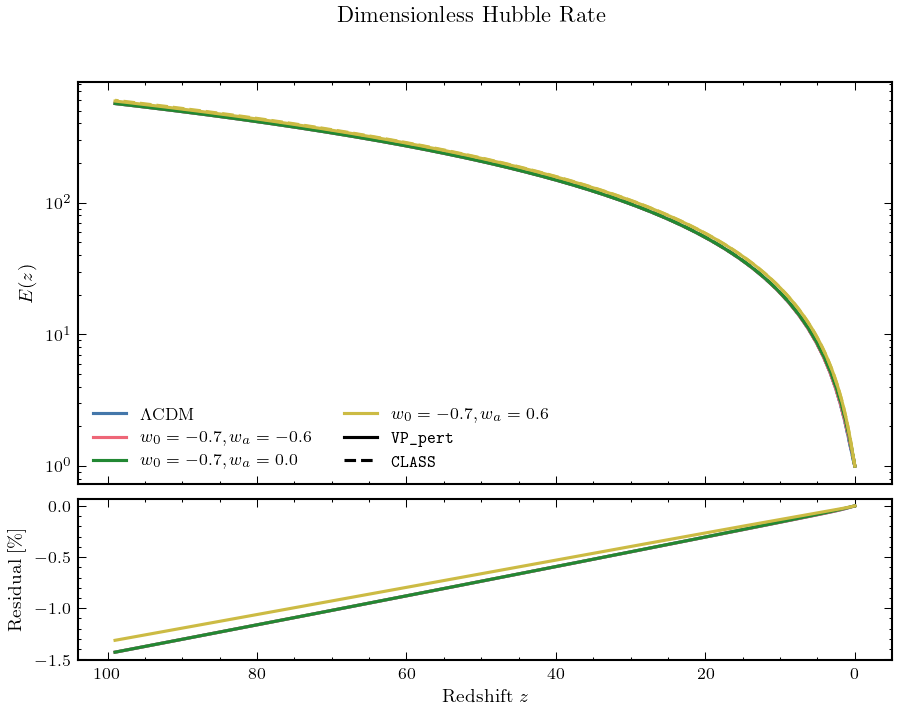

In [37]:
z_ini = 99

zz = np.linspace(0, z_ini, 1000)
aa = 1 / (1 + zz)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for idx, (label, (w0, wa)) in enumerate(de_models.items()):
    p = dict(vp_base)
    p['w0'], p['wa'] = w0, wa
    E_vp = vp.EHubble(aa, pars=p)
    E_cl = np.array([class_cosmos[label].Hubble(z) /class_cosmos[label].Hubble(0) for z in zz])

    
    ax1.semilogy(zz, E_vp, color=COLORS[idx], label=label)
    ax1.semilogy(zz, E_cl, color=COLORS[idx], ls='--')
    ax2.plot(zz, 100*(E_vp/E_cl-1.),color=COLORS[idx])

proxy = [Line2D([0],[0], color='k', lw=1.5,        label=r'\texttt{VP\_pert}'),
         Line2D([0],[0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]

handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles=handles+proxy, ncol=2)
ax1.set_ylabel(r'$E(z)$')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')
ax2.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax1.invert_xaxis()
fig.suptitle('Dimensionless Hubble Rate')

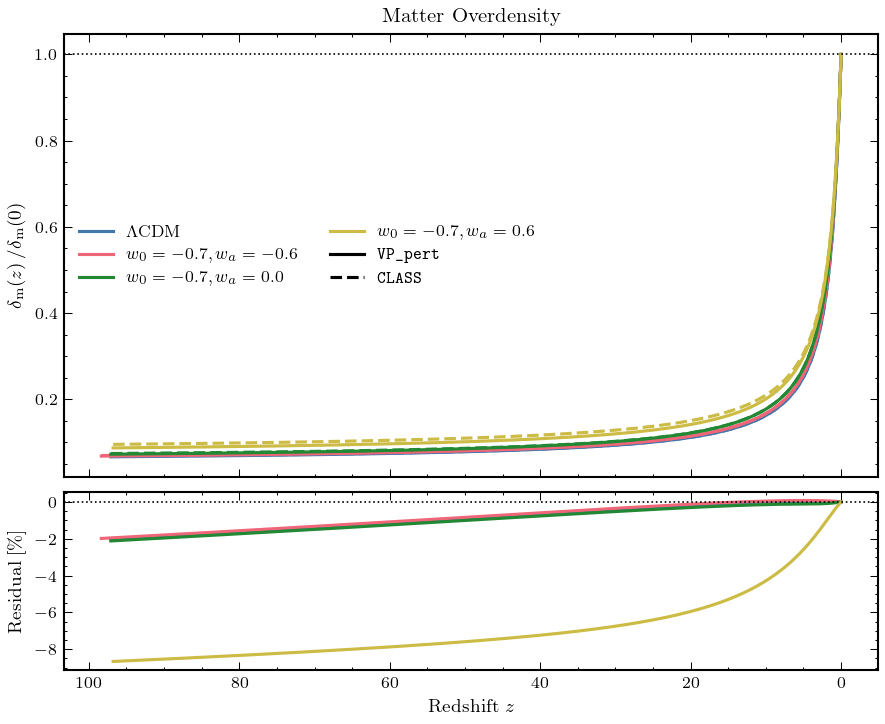

In [61]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (label, (w0, wa)) in enumerate(de_models.items()):
    delta_m_vp, zz_vp = get_delta_m_class(class_cosmos[label], pert_name='delta_m')
    delta_m_cl = get_delta_m_vp(vp_sols[label], zz_vp, idx_X=0)
    
    delta_m_vp_norm = delta_m_vp/delta_m_vp[-1]
    delta_m_cl_norm = delta_m_cl/delta_m_cl[-1]

    ax1.plot(zz_vp, delta_m_vp_norm, color=COLORS[i], lw=1.5, label=label)
    ax1.plot(zz_vp, delta_m_cl_norm, color=COLORS[i], lw=1.5, ls='--')
    ax2.plot(zz_vp, 100*(delta_m_vp_norm/delta_m_cl_norm - 1), color=COLORS[i])

handles, labels = ax1.get_legend_handles_labels()
custom = [Line2D([0], [0], color='k', lw=1.5,       label=r'\texttt{VP\_pert}'),
          Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)

ax1.axhline(1, color='k', lw=0.8, ls=':')
ax1.set_ylabel(r'$\delta_{\rm m}(z)\,/\delta_{\rm m}(0)$')
ax1.set_title(r'Matter Overdensity')

ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')

ax1.invert_xaxis()


# fig.tight_layout()
plt.savefig('figs/delta_m.pdf', bbox_inches='tight')
plt.show()

for c in class_cosmos.values():
    c.struct_cleanup()

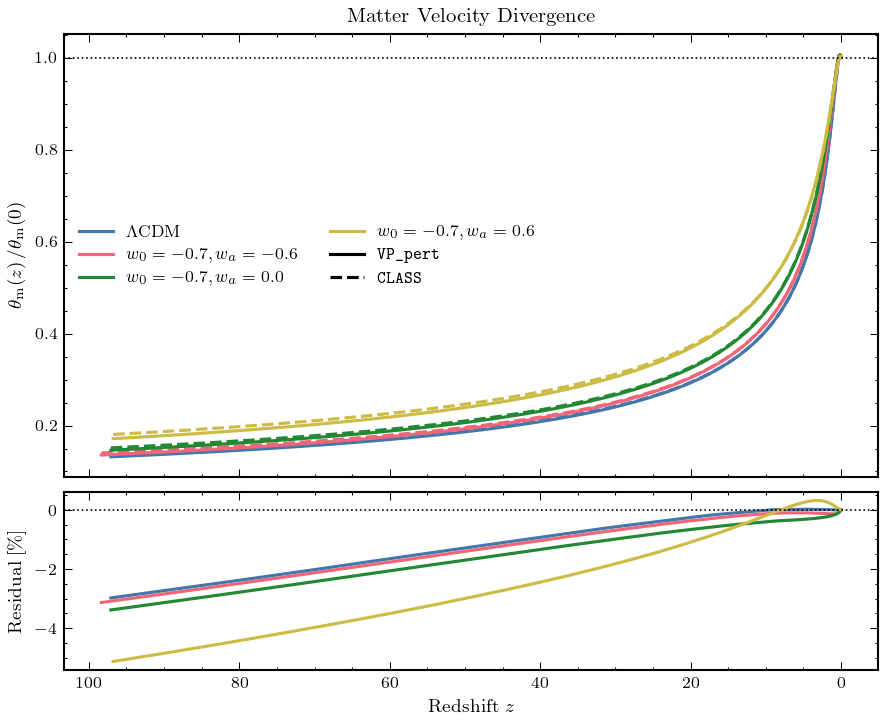

In [60]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (label, (w0, wa)) in enumerate(de_models.items()):
    delta_m_vp, zz_vp = get_delta_m_class(class_cosmos[label], pert_name='theta_m')
    delta_m_cl = get_delta_m_vp(vp_sols[label], zz_vp, idx_X=1)
    
    delta_m_vp_norm = delta_m_vp/delta_m_vp[-1]
    delta_m_cl_norm = delta_m_cl/delta_m_cl[-1]

    ax1.plot(zz_vp, delta_m_vp_norm, color=COLORS[i], lw=1.5, label=label)
    ax1.plot(zz_vp, delta_m_cl_norm, color=COLORS[i], lw=1.5, ls='--')
    ax2.plot(zz_vp, 100*(delta_m_vp_norm/delta_m_cl_norm - 1), color=COLORS[i])

handles, labels = ax1.get_legend_handles_labels()
custom = [Line2D([0], [0], color='k', lw=1.5,       label=r'\texttt{VP\_pert}'),
          Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)

ax1.axhline(1, color='k', lw=0.8, ls=':')
ax1.set_ylabel(r'$\theta_{\rm m}(z)\,/\theta_{\rm m}(0)$')
ax1.set_title(r'Matter Velocity Divergence')

ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')

ax1.invert_xaxis()


# fig.tight_layout()
plt.savefig('figs/theta_m.pdf', bbox_inches='tight')
plt.show()

for c in class_cosmos.values():
    c.struct_cleanup()

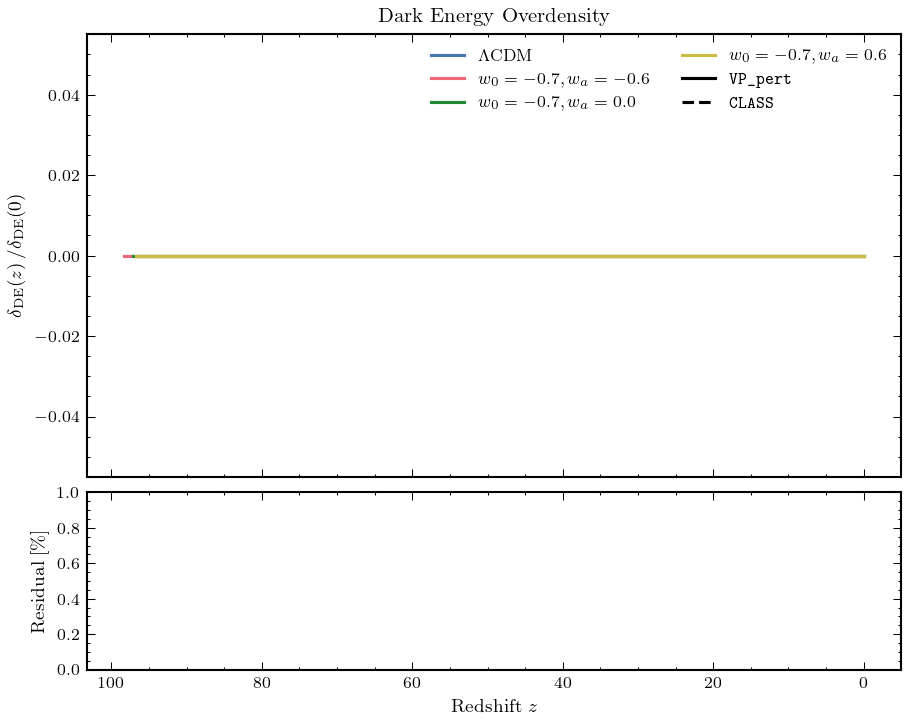

In [59]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (label, (w0, wa)) in enumerate(de_models.items()):
    delta_m_vp, zz_vp = get_delta_m_class(class_cosmos[label], pert_name='delta_de')
    delta_m_cl = get_delta_m_vp(vp_sols[label], zz_vp, idx_X=2)
    
    # delta_m_vp_norm = delta_m_vp/delta_m_vp[-1]
    # delta_m_cl_norm = delta_m_cl/delta_m_cl[-1]

    ax1.plot(zz_vp, delta_m_vp, color=COLORS[i], lw=1.5, label=label)
    # ax1.plot(zz_vp, delta_m_cl, color=COLORS[i], lw=1.5, ls='--')
    # ax2.plot(zz_vp, 100*(delta_m_vp/delta_m_cl - 1), color=COLORS[i])

handles, labels = ax1.get_legend_handles_labels()
custom = [Line2D([0], [0], color='k', lw=1.5,       label=r'\texttt{VP\_pert}'),
          Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)

ax1.set_ylabel(r'$\delta_{\rm DE}(z)\,/\delta_{\rm DE}(0)$')
ax1.set_title(r'Dark Energy Overdensity')

ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')

ax1.invert_xaxis()


# fig.tight_layout()
plt.savefig('figs/delta_de.pdf', bbox_inches='tight')
plt.show()

for c in class_cosmos.values():
    c.struct_cleanup()

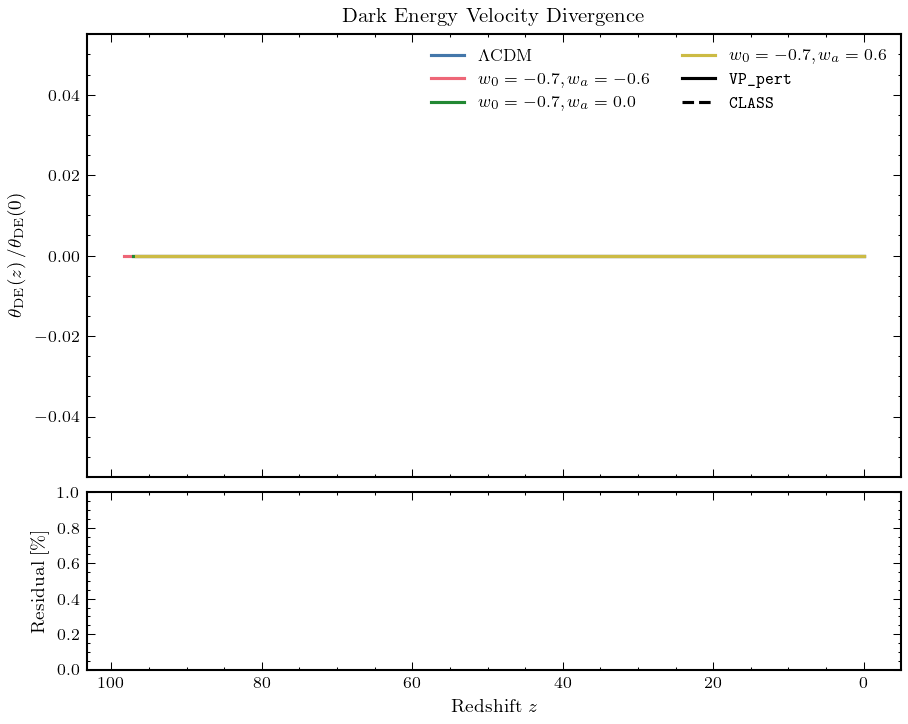

In [58]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True, gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.05})

for i, (label, (w0, wa)) in enumerate(de_models.items()):
    delta_m_vp, zz_vp = get_delta_m_class(class_cosmos[label], pert_name='theta_de')
    delta_m_cl = get_delta_m_vp(vp_sols[label], zz_vp, idx_X=3)
    
    # delta_m_vp_norm = delta_m_vp/delta_m_vp[-1]
    # delta_m_cl_norm = delta_m_cl/delta_m_cl[-1]

    ax1.plot(zz_vp, delta_m_vp, color=COLORS[i], lw=1.5, label=label)
    # ax1.plot(zz_vp, delta_m_cl, color=COLORS[i], lw=1.5, ls='--')
    # ax2.plot(zz_vp, 100*(delta_m_vp/delta_m_cl - 1), color=COLORS[i])

handles, labels = ax1.get_legend_handles_labels()
custom = [Line2D([0], [0], color='k', lw=1.5,       label=r'\texttt{VP\_pert}'),
          Line2D([0], [0], color='k', lw=1.5, ls='--', label=r'\texttt{CLASS}')]
ax1.legend(handles=handles + custom, fontsize=8, ncol=2)

ax1.set_ylabel(r'$\theta_{\rm DE}(z)\,/\theta_{\rm DE}(0)$')
ax1.set_title(r'Dark Energy Velocity Divergence')

ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'Residual [\%]')

ax1.invert_xaxis()


# fig.tight_layout()
plt.savefig('figs/theta_de.pdf', bbox_inches='tight')
plt.show()

for c in class_cosmos.values():
    c.struct_cleanup()